In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy.stats import linregress

In [2]:
project_path = Path.cwd().parent

raw_path = project_path / "data" / "raw"

reports_path = project_path / "reports"

In [3]:
nav = pd.read_csv(raw_path / "02_nav_history.csv")

performance = pd.read_csv(
    raw_path / "07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    raw_path / "10_benchmark_indices.csv"
)

fund_master = pd.read_csv(
    raw_path / "01_fund_master.csv"
)

In [7]:
# Daily Return Calculation

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210


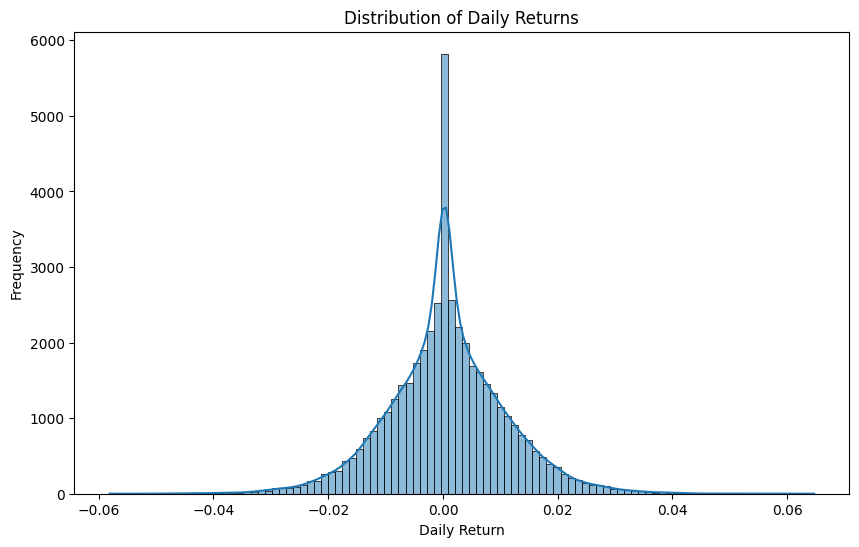

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [9]:
print("Minimum Return:")
print(nav["daily_return"].min())

print()

print("Maximum Return:")
print(nav["daily_return"].max())

print()

print(nav["daily_return"].describe())

Minimum Return:
-0.058102013949189124

Maximum Return:
0.06471309359097144

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [10]:
# CAGR Calculation

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    latest_nav = fund_data.iloc[-1]["nav"]
    latest_date = fund_data.iloc[-1]["date"]

    result = {
        "amfi_code": fund
    }

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        historical = fund_data[
            fund_data["date"] <= start_date
        ]

        if len(historical) > 0:

            start_nav = historical.iloc[-1]["nav"]

            cagr = (
                (latest_nav / start_nav)
                ** (1 / years)
                - 1
            ) * 100

            result[f"CAGR_{years}Y"] = round(cagr, 2)

        else:

            result[f"CAGR_{years}Y"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,NaN
1,100025,3.70,3.92,NaN
2,100033,53.23,32.44,NaN
3,101206,47.92,28.97,NaN
4,101207,-23.99,-4.15,NaN


In [11]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
0,100016,-2.22,1.29,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,3.70,3.92,NaN,HDFC Short Term Debt Fund - Regular - Growth
2,100033,53.23,32.44,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,47.92,28.97,NaN,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-23.99,-4.15,NaN,ABSL Small Cap Fund - Regular - Growth


In [12]:
cagr_df.sort_values(
    "CAGR_3Y",
    ascending=False
).head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,scheme_name
16,119094,22.26,35.11,NaN,Axis Midcap Fund - Regular - Growth
34,148567,20.36,34.00,NaN,Mirae Asset Large Cap Fund - Regular - Growth
24,120504,13.06,32.49,NaN,ICICI Pru Bluechip Fund - Direct - Growth
2,100033,53.23,32.44,NaN,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,29.60,31.78,NaN,ICICI Pru Midcap Fund - Regular - Growth
19,119551,60.44,30.46,NaN,SBI Bluechip Fund - Regular Plan - Growth
30,120843,26.66,29.58,NaN,Kotak Flexicap Fund - Regular - Growth
36,148569,39.75,29.18,NaN,Mirae Asset Tax Saver Fund - Regular - Growth
3,101206,47.92,28.97,NaN,ABSL Frontline Equity Fund - Regular - Growth
39,149324,65.14,27.00,NaN,DSP Small Cap Fund - Regular - Growth


In [45]:
cagr_df.to_csv(
    reports_path / "cagr_comparison.csv",
    index=False
)

print("cagr_comparison.csv saved")

cagr_comparison.csv saved


In [14]:
# Sharpe Ratio Calculation

risk_free_rate = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = returns.std() * np.sqrt(252)

    sharpe = (
        (annual_return - risk_free_rate)
        / annual_volatility
    )

    sharpe_results.append(
        {
            "amfi_code": fund,
            "sharpe_ratio": round(sharpe, 4)
        }
    )

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.2015
1,100025,-0.5671
2,100033,1.0937
3,101206,1.0272
4,101207,0.1627


In [15]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.4483,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.3067,Kotak Flexicap Fund - Regular - Growth
36,148569,1.2349,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.2083,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.1801,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.1321,DSP Midcap Fund - Regular - Growth
2,100033,1.0937,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.0817,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.0272,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.0265,ICICI Pru Bluechip Fund - Direct - Growth


In [16]:
# Sortino Ratio Calculation

sortino_results = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside_returns = returns[
        returns < 0
    ]

    annual_return = returns.mean() * 252

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        (annual_return - risk_free_rate)
        / downside_std
    )

    sortino_results.append(
        {
            "amfi_code": fund,
            "sortino_ratio": round(sortino, 4)
        }
    )

sortino_df = pd.DataFrame(
    sortino_results
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.3510
1,100025,-0.9418
2,100033,1.8291
3,101206,1.7996
4,101207,0.2766


In [17]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.3856,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.3643,Kotak Flexicap Fund - Regular - Growth
36,148569,2.1469,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.1403,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.0294,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.8751,DSP Midcap Fund - Regular - Growth
9,118632,1.8501,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.8291,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.8053,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.7996,ABSL Frontline Equity Fund - Regular - Growth


In [18]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(5)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.4483,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.3067,Kotak Flexicap Fund - Regular - Growth
36,148569,1.2349,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.2083,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.1801,ICICI Pru Midcap Fund - Regular - Growth


In [19]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(5)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.3856,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.3643,Kotak Flexicap Fund - Regular - Growth
36,148569,2.1469,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.1403,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.0294,ICICI Pru Midcap Fund - Regular - Growth


In [20]:
# Prepare NIFTY100 benchmark returns

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [21]:
# Alpha & Beta Calculation

alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = nav[
        ["amfi_code", "date", "daily_return"]
    ]

    fund_returns = fund_returns[
        fund_returns["amfi_code"] == fund
    ]

    merged = fund_returns.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope

        alpha = regression.intercept * 252

        alpha_beta_results.append(
            {
                "amfi_code": fund,
                "alpha": round(alpha, 4),
                "beta": round(beta, 4)
            }
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [22]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.3034,-0.0232,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.3006,0.0115,DSP Small Cap Fund - Regular - Growth
25,120505,0.2926,0.0005,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.2827,0.0181,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.2733,-0.0228,Kotak Flexicap Fund - Regular - Growth
2,100033,0.2720,0.0051,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.2698,0.0237,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.2660,-0.0025,DSP Midcap Fund - Regular - Growth
16,119094,0.2608,-0.0663,Axis Midcap Fund - Regular - Growth
19,119551,0.2320,-0.0318,SBI Bluechip Fund - Regular Plan - Growth


In [23]:
alpha_beta_df.to_csv(
    reports_path / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [24]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(5)

,amfi_code,alpha,beta,scheme_name
21,119598,0.3034,-0.0232,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.3006,0.0115,DSP Small Cap Fund - Regular - Growth
25,120505,0.2926,0.0005,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.2827,0.0181,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.2733,-0.0228,Kotak Flexicap Fund - Regular - Growth


In [25]:
# Maximum Drawdown Calculation

mdd_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ].sort_values("date").copy()

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    worst_row = fund_data.loc[
        fund_data["drawdown"].idxmin()
    ]

    mdd_results.append({
        "amfi_code": fund,
        "max_drawdown": round(
            worst_row["drawdown"] * 100,
            2
        ),
        "worst_date": worst_row["date"]
    })

mdd_df = pd.DataFrame(
    mdd_results
)

mdd_df.head()

,amfi_code,max_drawdown,worst_date
0,100016,-24.73,2022-09-15
1,100025,-4.31,2023-07-28
2,100033,-16.22,2022-05-12
3,101206,-11.29,2023-07-05
4,101207,-35.45,2026-05-11


In [26]:
mdd_df = mdd_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

mdd_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,worst_date,scheme_name
22,119599,-52.57,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.68,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.45,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.17,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.71,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-28.00,2026-04-27,UTI Mid Cap Fund - Regular - Growth
0,100016,-24.73,2022-09-15,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-24.00,2024-10-17,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-23.34,2026-02-20,Nippon India Small Cap Fund - Regular - Growth
15,119093,-21.75,2023-05-22,Axis Bluechip Fund - Direct - Growth


In [27]:
mdd_df.to_csv(
    reports_path / "max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved")

max_drawdown.csv saved


In [28]:
worst_fund = mdd_df.sort_values(
    "max_drawdown"
).iloc[0]

worst_fund

amfi_code                                          119599
max_drawdown                                       -52.57
worst_date                            2025-10-28 00:00:00
scheme_name     SBI Small Cap Fund - Direct Plan - Growth
Name: 22, dtype: object

In [29]:
mdd_df.sort_values(
    "max_drawdown"
).head(5)

,amfi_code,max_drawdown,worst_date,scheme_name
22,119599,-52.57,2025-10-28,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-51.68,2026-05-11,Axis Small Cap Fund - Regular - Growth
4,101207,-35.45,2026-05-11,ABSL Small Cap Fund - Regular - Growth
39,149324,-31.17,2025-01-03,DSP Small Cap Fund - Regular - Growth
21,119598,-28.71,2025-05-14,SBI Small Cap Fund - Regular Plan - Growth


In [30]:
scorecard = cagr_df[
    ["amfi_code", "scheme_name", "CAGR_3Y"]
].copy()

scorecard = scorecard.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    mdd_df[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,-24.73,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,-4.31,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,-16.22,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,-11.29,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,-35.45,1.53


In [32]:
scorecard["return_rank"] = (
    scorecard["CAGR_3Y"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["mdd_rank"] = (
    (-abs(scorecard["max_drawdown"]))
    .rank(pct=True)
)

In [33]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["mdd_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

scorecard.head()

,amfi_code,scheme_name,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,1.29,-0.2015,0.0375,-24.73,1.55,0.150,0.150,0.050,0.2250,0.175,14.38
1,100025,HDFC Short Term Debt Fund - Regular - Growth,3.92,-0.5671,0.0428,-4.31,0.56,0.175,0.050,0.075,0.9750,0.925,31.88
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,-16.22,1.38,0.925,0.850,0.875,0.6000,0.525,80.75
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,-11.29,1.60,0.800,0.800,0.725,0.1125,0.800,68.19
4,101207,ABSL Small Cap Fund - Regular - Growth,-4.15,0.1627,0.1090,-35.45,1.53,0.050,0.325,0.350,0.3125,0.075,22.06


In [34]:
scorecard.sort_values(
    "fund_score",
    ascending=False
).head(10)

,amfi_code,scheme_name,CAGR_3Y,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,mdd_rank,fund_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,34.00,1.4483,0.2698,-11.27,1.46,0.975,1.000,0.850,0.4500,0.825,86.25
25,120505,ICICI Pru Midcap Fund - Regular - Growth,31.78,1.1801,0.2926,-18.19,1.36,0.900,0.900,0.950,0.6500,0.400,82.25
30,120843,Kotak Flexicap Fund - Regular - Growth,29.58,1.3067,0.2733,-12.97,1.45,0.850,0.975,0.900,0.4750,0.700,82.00
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,32.44,1.0937,0.2720,-16.22,1.38,0.925,0.850,0.875,0.6000,0.525,80.75
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,32.49,1.0265,0.2119,-12.59,0.80,0.950,0.775,0.700,0.7250,0.725,80.00
16,119094,Axis Midcap Fund - Regular - Growth,35.11,0.9982,0.2608,-20.96,1.38,1.000,0.750,0.800,0.6000,0.325,77.00
19,119551,SBI Bluechip Fund - Regular Plan - Growth,30.46,1.2083,0.2320,-15.01,1.54,0.875,0.925,0.775,0.2625,0.600,74.81
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,29.18,1.2349,0.2827,-16.40,1.60,0.825,0.950,0.925,0.1125,0.500,73.69
3,101206,ABSL Frontline Equity Fund - Regular - Growth,28.97,1.0272,0.2140,-11.29,1.60,0.800,0.800,0.725,0.1125,0.800,68.19
21,119598,SBI Small Cap Fund - Regular Plan - Growth,26.67,0.9453,0.3034,-28.71,1.43,0.725,0.675,1.000,0.5000,0.125,67.38


In [35]:
scorecard.to_csv(
    reports_path / "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


# Benchmark Comparison

In [37]:
top5_codes = (
    scorecard
    .sort_values("fund_score", ascending=False)
    .head(5)["amfi_code"]
    .tolist()
)

top5_codes

[148567, 120505, 120843, 100033, 120504]

In [39]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

top5_nav = top5_nav.sort_values("date")

In [40]:
top5_nav["normalized"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [41]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

bench_plot = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

bench_plot["normalized"] = (
    bench_plot.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

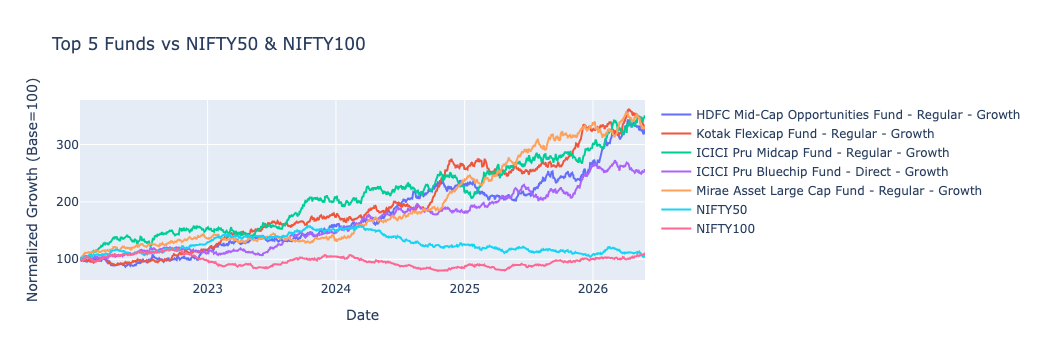

In [42]:
import plotly.graph_objects as go

fig = go.Figure()

for fund in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == fund
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            name=fund
        )
    )

for idx in ["NIFTY50", "NIFTY100"]:

    temp = bench_plot[
        bench_plot["index_name"] == idx
    ]

    fig.add_trace(
        go.Scatter(
            x=temp["date"],
            y=temp["normalized"],
            name=idx
        )
    )

fig.update_layout(
    title="Top 5 Funds vs NIFTY50 & NIFTY100",
    xaxis_title="Date",
    yaxis_title="Normalized Growth (Base=100)"
)

fig.show()

In [43]:
fig.write_image(
    reports_path / "benchmark_comparison.png"
)

In [44]:
tracking_results = []

for fund in top5_codes:

    fund_returns = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = fund_returns.merge(
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["daily_return"]
         - merged["benchmark_return"])
        .std()
        * np.sqrt(252)
    )

    tracking_results.append({
        "amfi_code": fund,
        "tracking_error": round(
            tracking_error,
            4
        )
    })

tracking_df = pd.DataFrame(
    tracking_results
)

tracking_df = tracking_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

tracking_df

,amfi_code,tracking_error,scheme_name
0,148567,0.1897,Mirae Asset Large Cap Fund - Regular - Growth
1,120505,0.2320,ICICI Pru Midcap Fund - Regular - Growth
2,120843,0.2064,Kotak Flexicap Fund - Regular - Growth
3,100033,0.2287,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,120504,0.1916,ICICI Pru Bluechip Fund - Direct - Growth
